In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/indian-medicine-data/medicine_data.csv


In [12]:
df= pd.read_csv('/kaggle/input/indian-medicine-data/medicine_data.csv')
df.head()


,sub_category,product_name,salt_composition,product_price,product_manufactured,medicine_desc,side_effects,drug_interactions
0,Human Insulin Basal,Human Insulatard 40IU/ml Suspension for Injection,Insulin Isophane (40IU),₹133.93,Novo Nordisk India Pvt Ltd,Human Insulatard 40IU/ml Suspension for Inject...,"Hypoglycemia (low blood glucose level),Injecti...","{""drug"": [""Benazepril"", ""Captopril"", ""Enalapri..."
1,Human Insulin Basal,Insulin 40IU/ml Injection,Insulin Isophane (40IU),₹121.91,Sun Pharmaceutical Industries Ltd,Insulin 40IU/ml Injection is used to improve b...,"Hypoglycemia (low blood glucose level),Injecti...","{""drug"": [""Benazepril"", ""Captopril"", ""Enalapri..."
2,Human Insulin Basal,Huminsulin N 40IU/ml Injection,Insulin Isophane (40IU),₹133.45,Eli Lilly and Company India Pvt Ltd,Huminsulin N 40IU/ml Injection is used to impr...,"Hypoglycemia (low blood glucose level),Injecti...","{""drug"": [""Benazepril"", ""Captopril"", ""Enalapri..."
3,Human Insulin Basal,Insugen-N 40IU/ml Injection,Insulin Isophane (40IU),₹133.36,Biocon,Insugen-N 40IU/ml Injection is used to improve...,"Hypoglycemia (low blood glucose level),Injecti...","{""drug"": [""Benazepril"", ""Captopril"", ""Enalapri..."
4,Human Insulin Basal,Insulatard 100IU/ml Flexpen,Insulin Isophane (100IU/ml),₹401.03,Novo Nordisk India Pvt Ltd,Insulatard 100IU/ml Flexpen is used to improve...,"Hypoglycemia (low blood glucose level),Injecti...","{""drug"": [""Benazepril"", ""Captopril"", ""Enalapri..."


In [13]:
df.isnull().sum()/len(df)*100

sub_category            0.000000
product_name            0.000000
salt_composition        0.000000
product_price           9.936351
product_manufactured    0.000000
medicine_desc           0.000000
side_effects            0.000000
drug_interactions       0.000000
dtype: float64

In [14]:
df.dropna(subset=['product_price'],inplace= True, ignore_index= True)
df.isnull().sum()/len(df)*100

sub_category            0.0
product_name            0.0
salt_composition        0.0
product_price           0.0
product_manufactured    0.0
medicine_desc           0.0
side_effects            0.0
drug_interactions       0.0
dtype: float64

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
print(df.info())
df.describe(include='all').transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176169 entries, 0 to 176168
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   sub_category          176169 non-null  object
 1   product_name          176169 non-null  object
 2   salt_composition      176169 non-null  object
 3   product_price         176169 non-null  object
 4   product_manufactured  176169 non-null  object
 5   medicine_desc         176169 non-null  object
 6   side_effects          176169 non-null  object
 7   drug_interactions     176169 non-null  object
dtypes: object(8)
memory usage: 10.8+ MB
None


,count,unique,top,freq
sub_category,176169,240,Cephalosporins,24045
product_name,176169,6043,Taxim 1gm Injection,619
salt_composition,176169,2245,Cefpodoxime Proxetil (200mg),4314
product_price,176169,3782,₹130.9,1300
product_manufactured,176169,789,Sun Pharmaceutical Industries Ltd,18623
medicine_desc,176169,6043,Taxim 1gm Injection is an antibiotic medicine ...,619
side_effects,176169,1035,"Vomiting,Nausea,Diarrhea",7585
drug_interactions,176169,162,"{""drug"": [], ""brand"": [], ""effect"": []}",107737


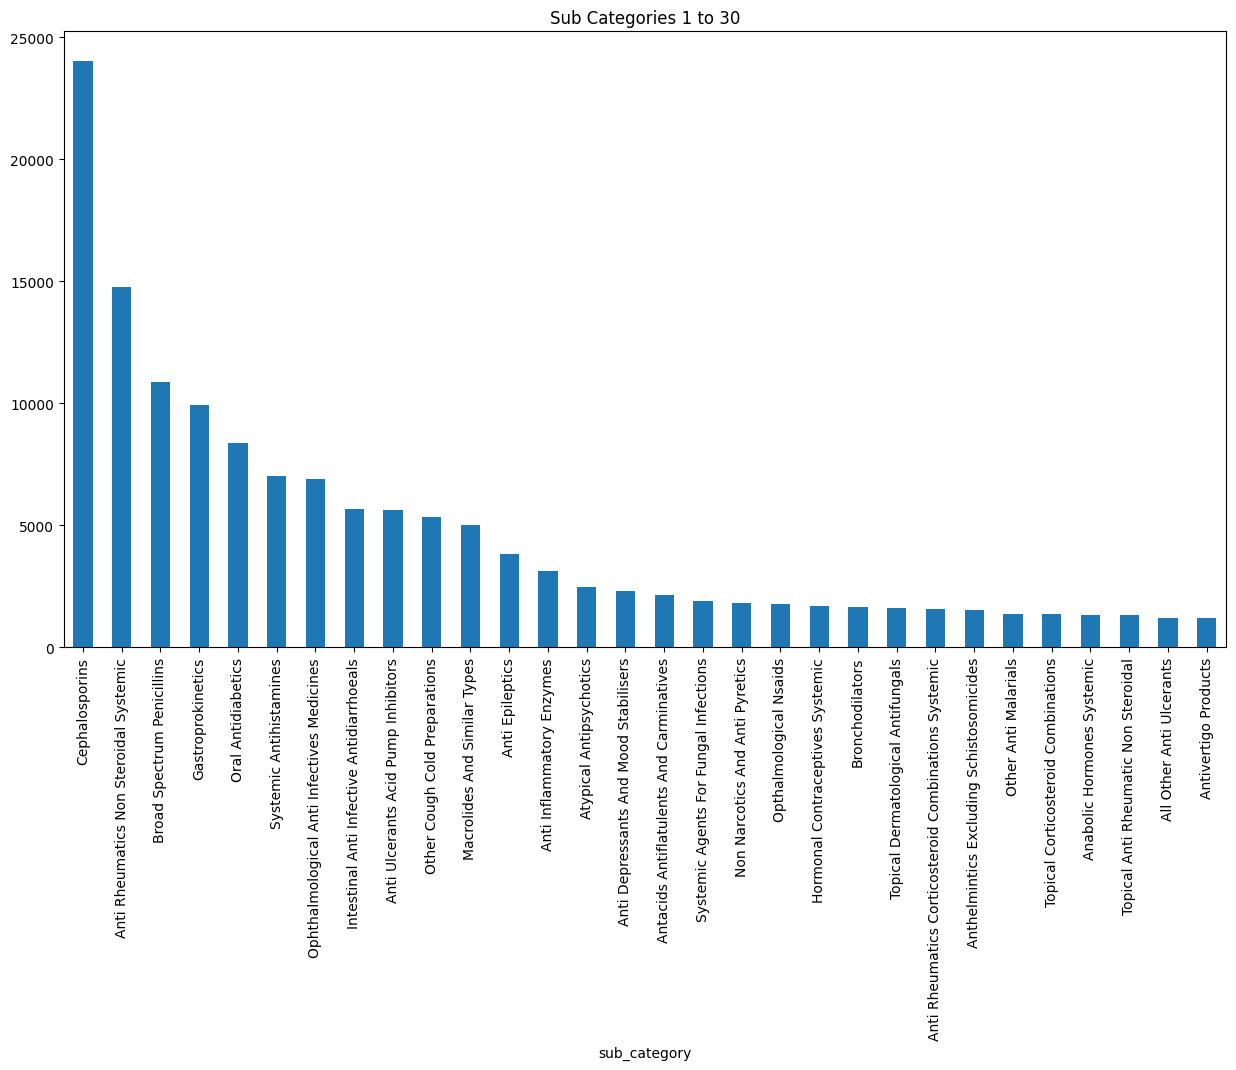

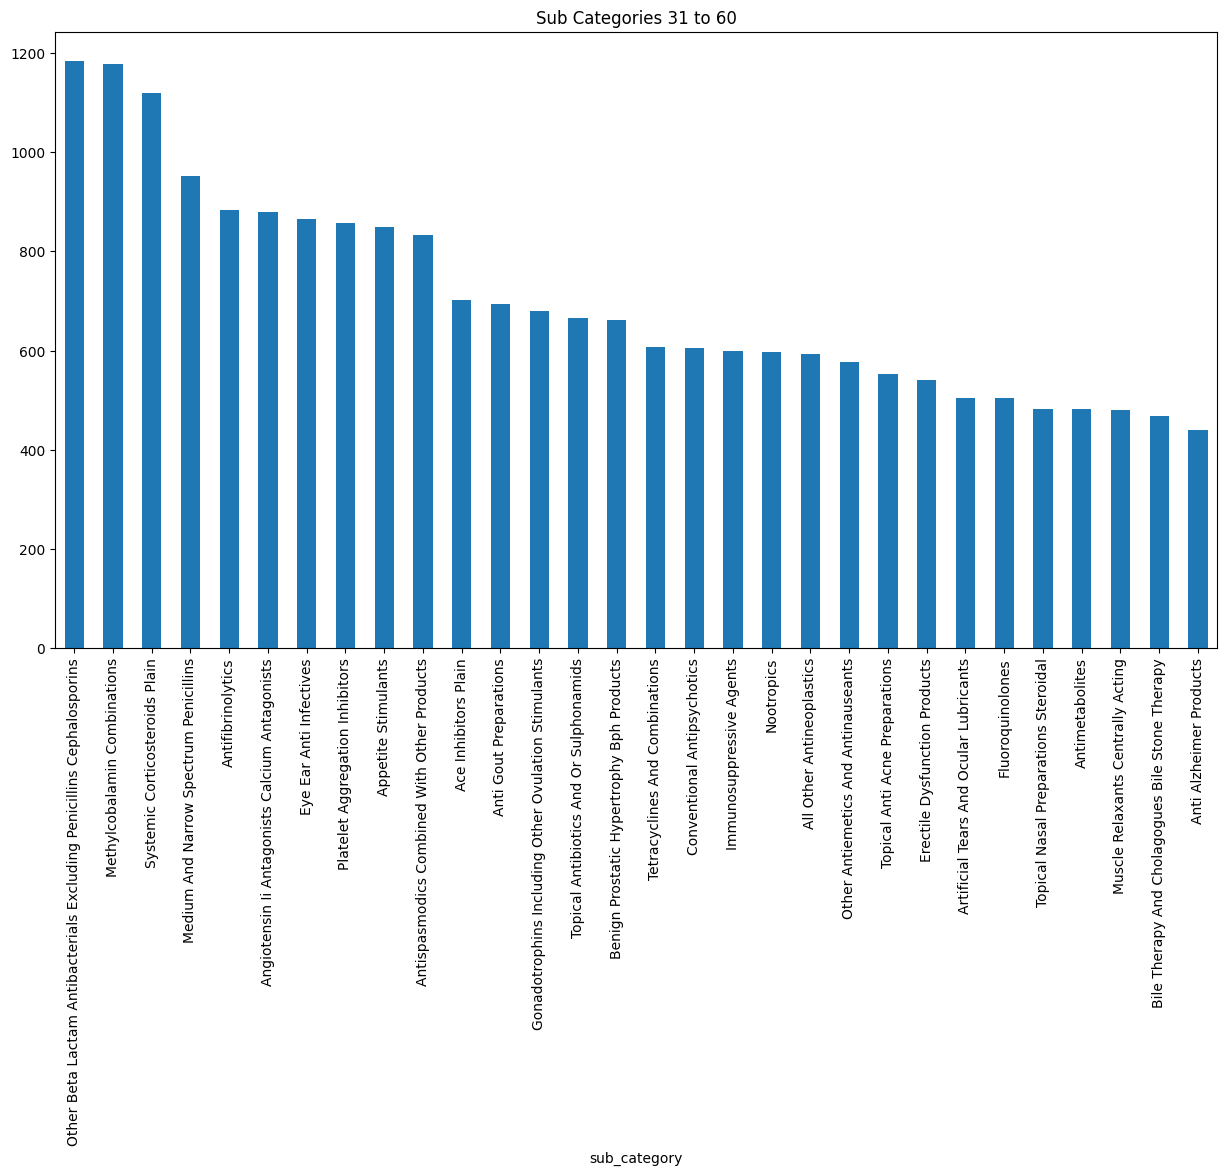

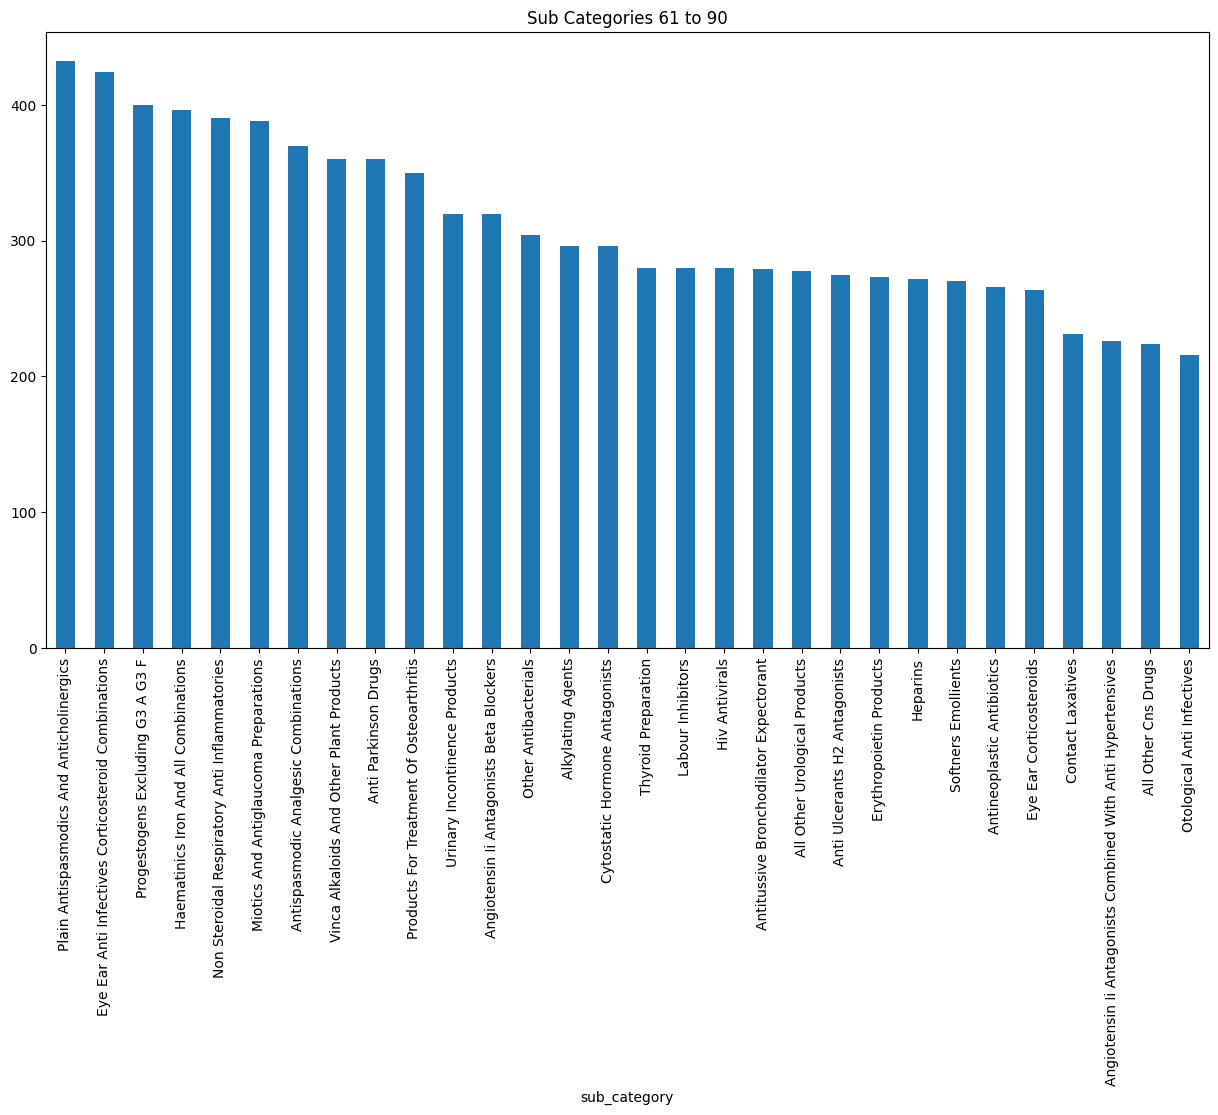

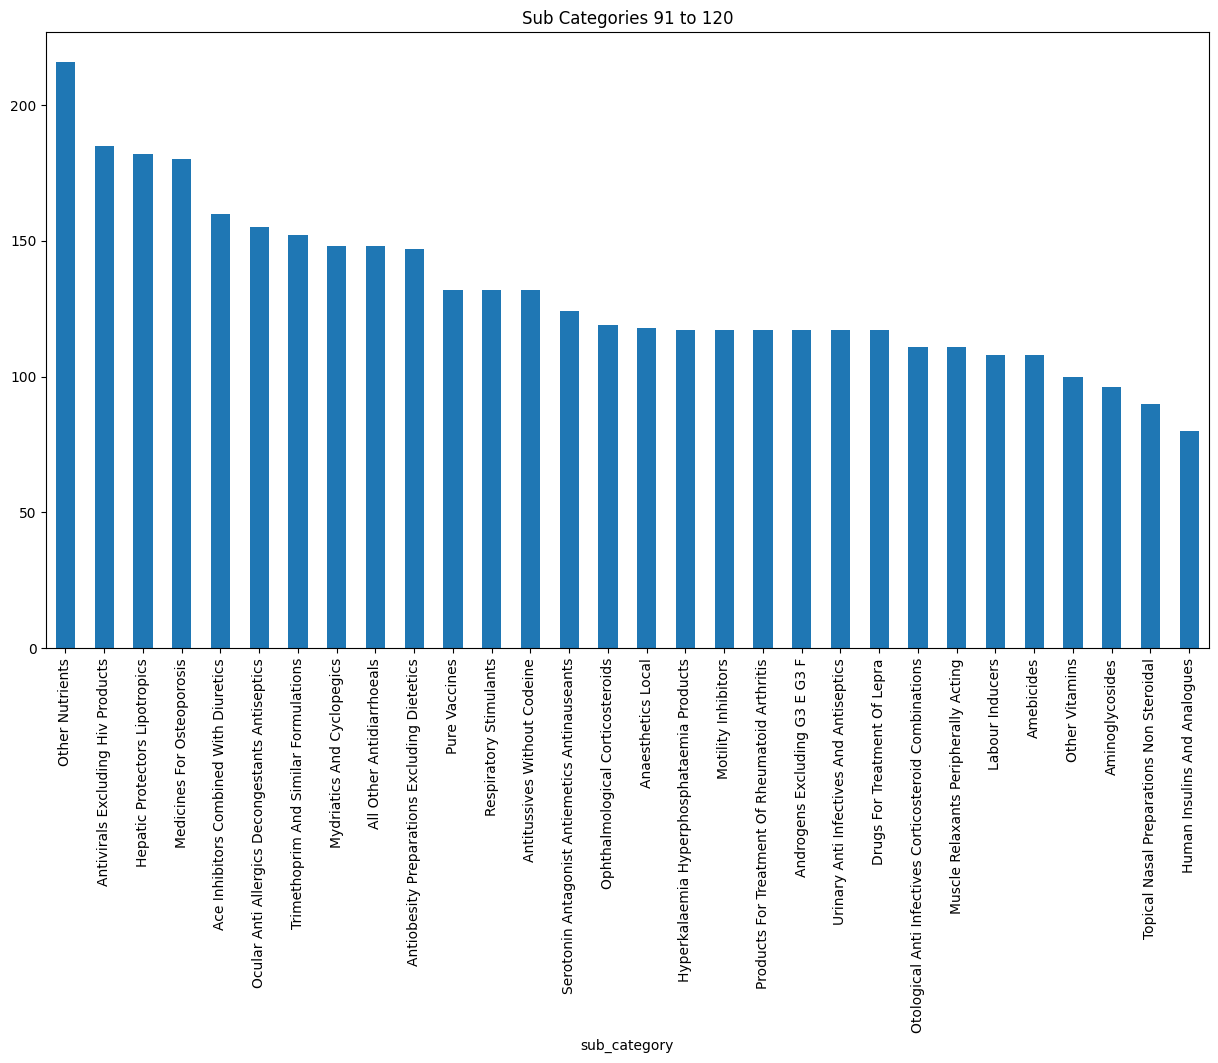

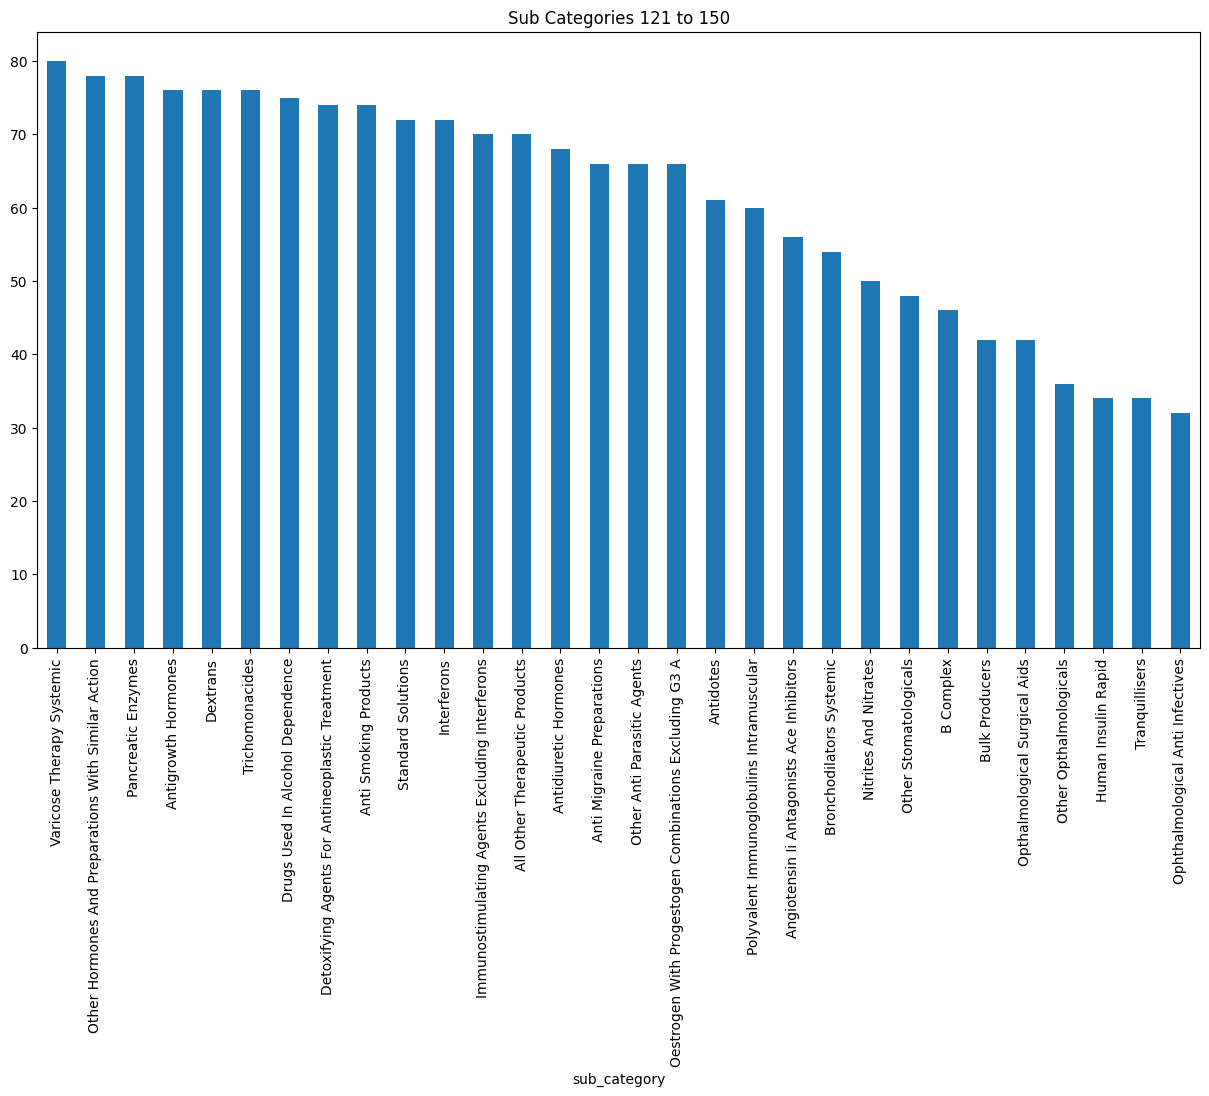

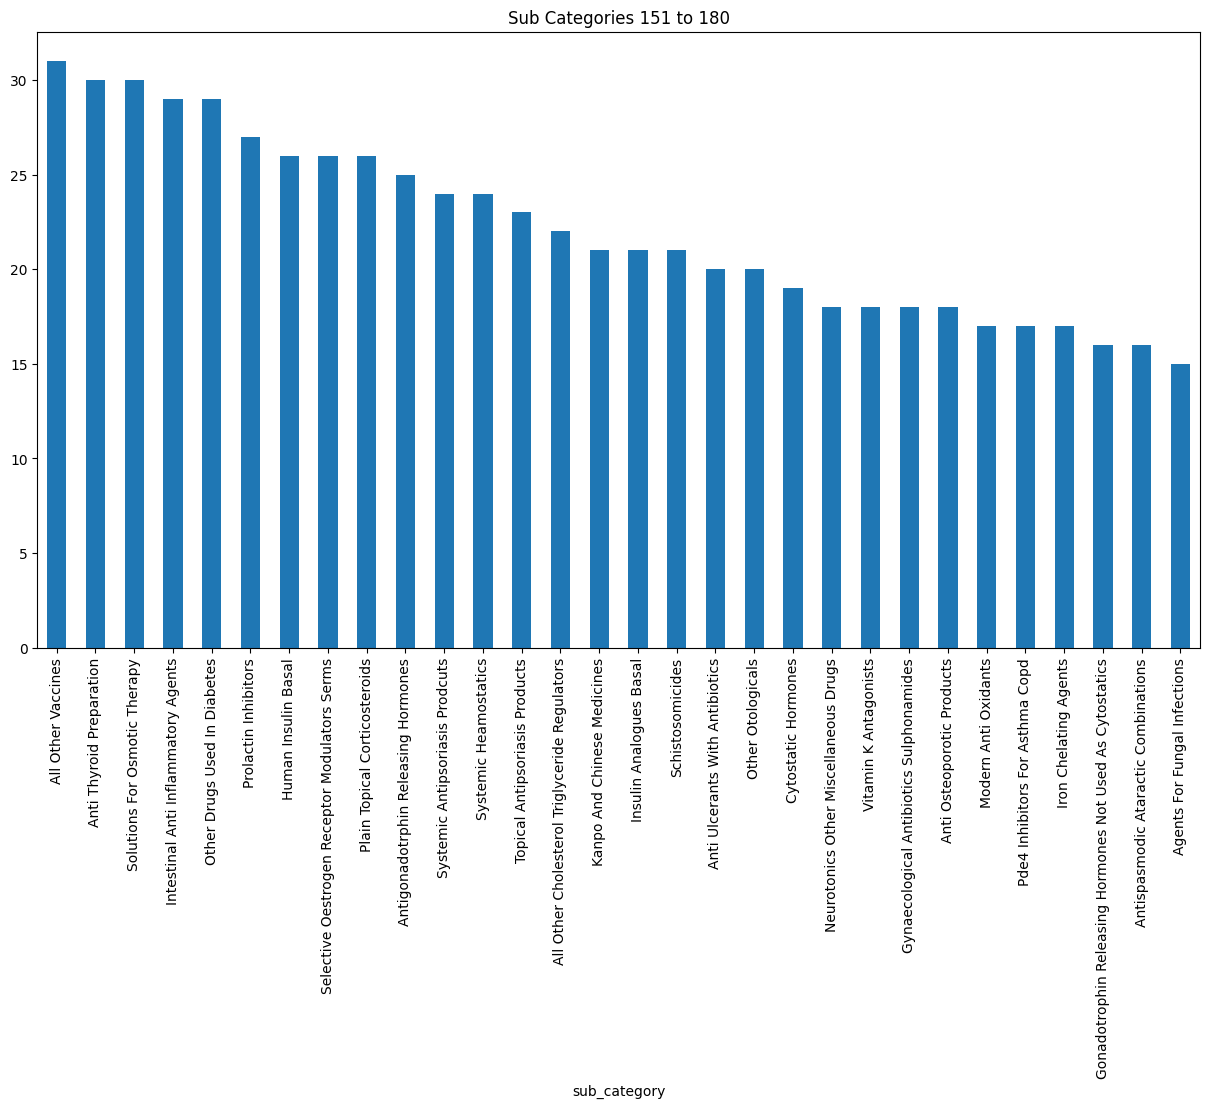

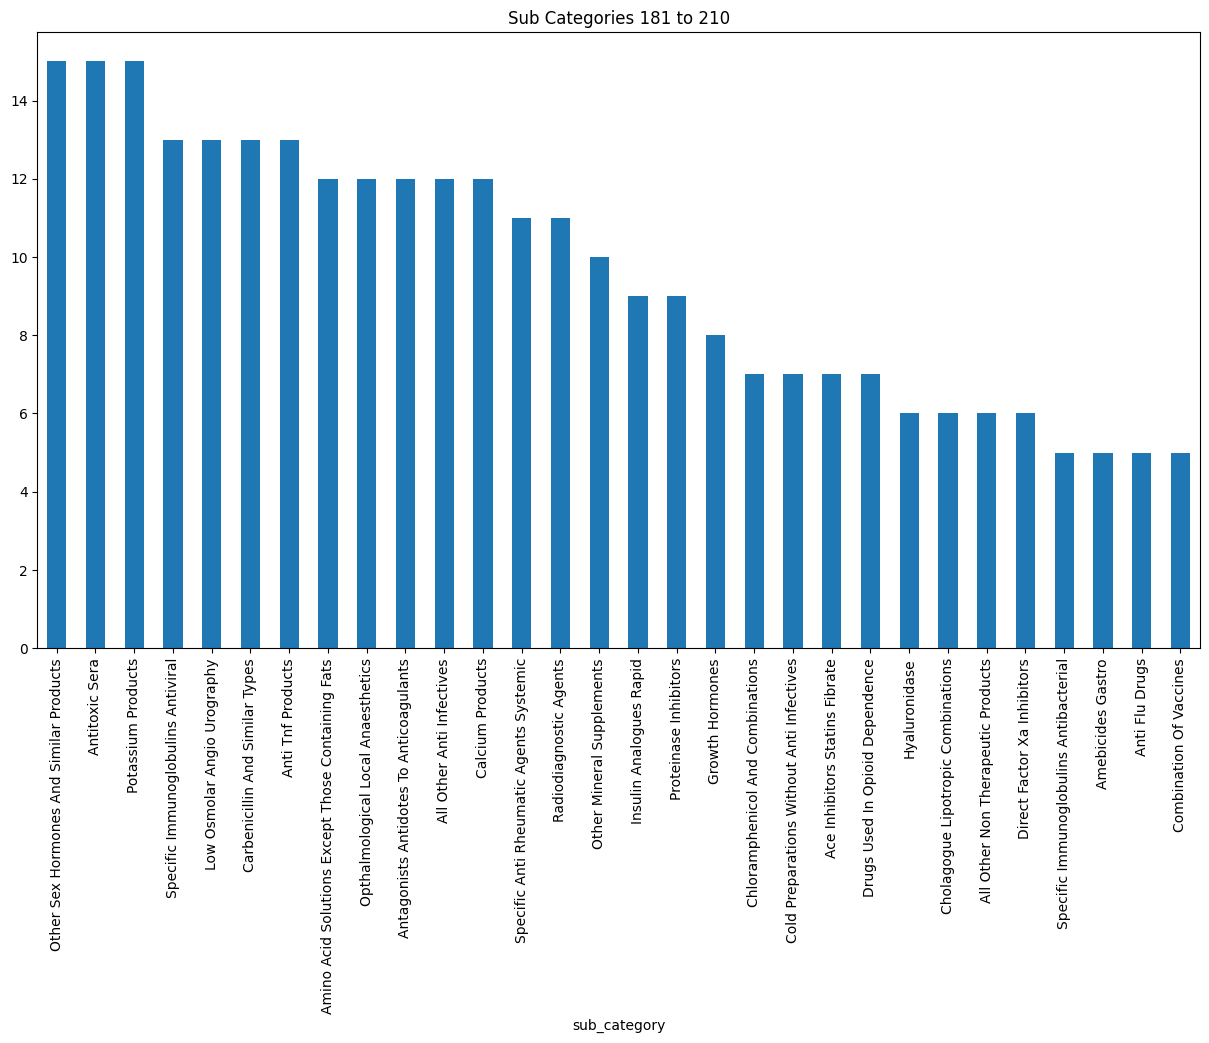

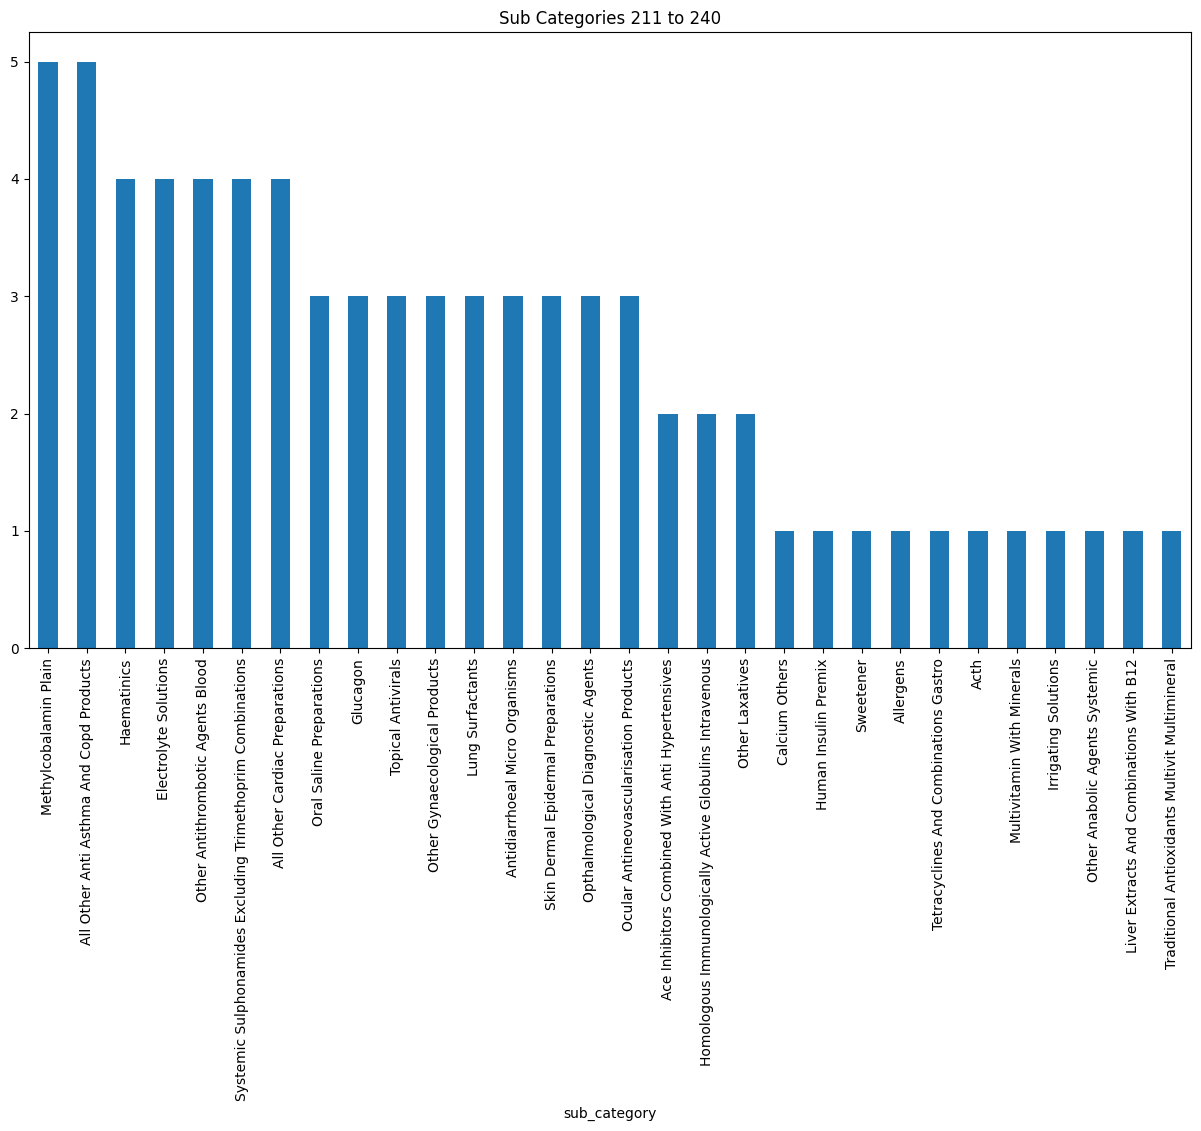

In [16]:
sub_counts = df['sub_category'].value_counts()
batch_size = 30

for i in range(0, len(sub_counts), batch_size):
    plt.figure(figsize=(15,8))
    sub_counts.iloc[i:i+batch_size].plot(kind='bar')
    plt.title(f"Sub Categories {i+1} to {i+batch_size}")
    plt.show()


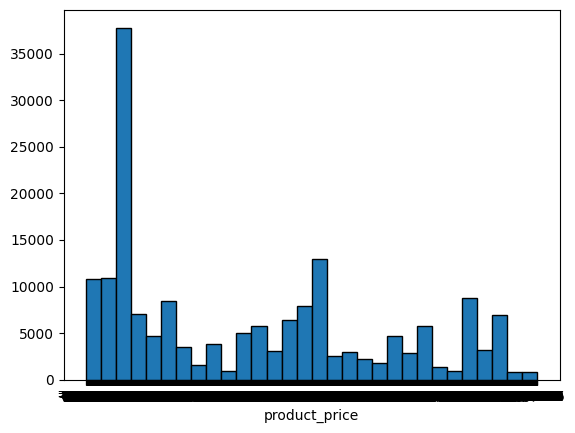

In [17]:
plt.hist(df['product_price'], bins=30, edgecolor='k')
plt.xlabel('product_price')
plt.show()

In [18]:
side_effect_counts = df['side_effects'].value_counts().head(20)
print(side_effect_counts)


side_effects
Vomiting,Nausea,Diarrhea                                                                                                       7585
Rash,Vomiting,Allergic reaction,Increased liver enzymes,Nausea,Diarrhea                                                        4317
Rash,Nausea,Diarrhea                                                                                                           4314
Nausea,Stomach pain,Indigestion,Diarrhea                                                                                       4313
No common side effects seen                                                                                                    3230
Nausea,Common cold,Cough,Blurred vision,Menstrual disorder                                                                     2940
Application site reactions (burning, irritation, itching and redness)                                                          2886
Vomiting,Nausea,Abdominal pain,Diarrhea                        

In [20]:
empty_interactions = (df['drug_interactions'] == '{"drug": [], "brand": [], "effect": []}').mean() * 100
print("Empty drug_interactions %:", empty_interactions)


Empty drug_interactions %: 61.15548138435253
